In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid")

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")   # Phase 3 reads from here

con = duckdb.connect()   # in-memory

# Register every Parquet file as a queryable view so the rest of the
# notebook can just say "FROM application_train" instead of a file path
TABLES = [
    "application_train", "application_test",
    "bureau", "bureau_balance",
    "previous_application", "POS_CASH_balance",
    "installments_payments", "credit_card_balance",
]
for t in TABLES:
    con.execute(f"""
        CREATE OR REPLACE VIEW {t} AS
        SELECT * FROM '{(PROCESSED / f"{t}.parquet").as_posix()}'
    """)

# Data dictionary — your reference for the leakage scan and special codes
col_desc = pd.read_csv(RAW / "HomeCredit_columns_description.csv",
                       encoding="latin-1", index_col=0)

print("Views:", con.execute("SHOW TABLES").df()["name"].tolist())

Views: ['POS_CASH_balance', 'application_test', 'application_train', 'bureau', 'bureau_balance', 'credit_card_balance', 'installments_payments', 'previous_application']


In [42]:
# Shape for train/test
df_train = con.execute("SELECT * FROM application_train").df()
df_test  = con.execute("SELECT * FROM application_test").df()

print(f"Train: {df_train.shape}\n")
print(f"Test: {df_test.shape}")
print(f"Train: {df_train.columns}\n")
print(f"Test: {df_test.columns}")
target_columns = df_train.columns
test_columns = df_test.columns

if "TARGET" in target_columns:
    print("The train df has the Target column")
else:
    print("Train df does not has the Target column")

if "TARGET" not in test_columns:
    print("Test df does not has the Target column")
else:
    print("The test df has the Target column")

if df_train["SK_ID_CURR"].nunique() == len(df_train["SK_ID_CURR"]):
    print("There are no duplications in Train df")
else:
    print("there are duplications in Train df")

if df_test["SK_ID_CURR"].nunique() == len(df_test["SK_ID_CURR"]):
    print("There are no duplications in Test df")
else:
    print("there are duplications in Test df")

train_set_sk = set(df_train["SK_ID_CURR"])
test_set_sk = set(df_test["SK_ID_CURR"])
overlap = train_set_sk & test_set_sk

if overlap == set():
    print("There are no duplication")
else:
    print(f"There are duplication: {overlap}")



Train: (307511, 122)

Test: (48744, 121)
Train: Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='str', length=122)

Test: Index(['SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR',
       'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 

In [53]:
# splitting to numerical, categorical and binary
def get_column_lists(df):
    binary = [col for col in df.columns if col.startswith("FLAG_")]
    numeric = [col for col in df.select_dtypes(include=["number"]).columns if col not in binary]
    categorical = [col for col in df.select_dtypes(include=['str', 'category']).columns if df[col].nunique() > 2]
    return numeric, categorical, binary

numeric_data, categorical_data, binary_data = get_column_lists(df_train)

print(f"Numeric:     {len(numeric_data)} columns")
print(f"Categorical: {len(categorical_data)} columns")
print(f"Binary FLAG: {len(binary_data)} columns\n")

print(f"Numeric: {numeric_data}\n")
print(f"Categorical: {categorical_data}\n")
print(f"Binary FLAG: {binary_data}")

Numeric:     80 columns
Categorical: 12 columns
Binary FLAG: 28 columns

Numeric: ['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'C

In [81]:
# STEP 2 Target / bad-rate analysis
df_target = df_train["TARGET"]

# counting the unique values
print(df_target.value_counts())
print(df_target.value_counts(normalize=True))
total_default = df_target.value_counts()[1]
total_non_default = df_target.value_counts()[0]
print(f"Total number of default is: {total_default}")
print(f"Total number of non default is: {total_non_default}")
default_percent = total_default / len(df_target) * 100
print(f"The % of default is: {default_percent:.3f}")




TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0   0.919
1   0.081
Name: proportion, dtype: float64
Total number of default is: 24825
Total number of non default is: 282686
The % of default is: 8.073


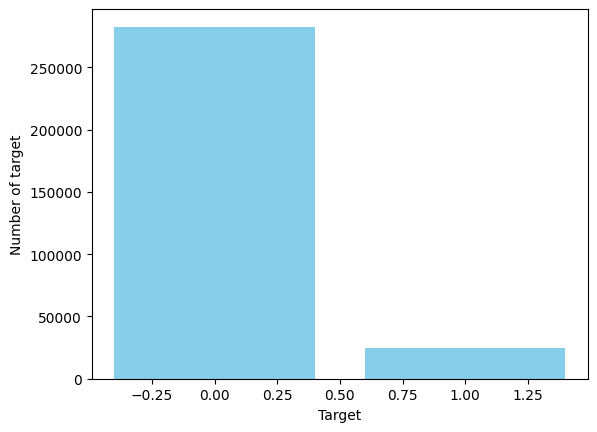

In [94]:
plt.bar(df_target.value_counts().index,df_target.value_counts().values, color="skyblue")
plt.xlabel("Target")
plt.ylabel("Number of target")
plt.show()

In [102]:
# Step 3 — Feature typing, cardinality & special codes
# Cardinality
for i in categorical_data:
    if i in df_train.columns:
        print(f"{i}: {df_train[i].nunique()}")

df_train["CODE_GENDER"].value_counts()



CODE_GENDER: 3
NAME_TYPE_SUITE: 7
NAME_INCOME_TYPE: 8
NAME_EDUCATION_TYPE: 5
NAME_FAMILY_STATUS: 6
NAME_HOUSING_TYPE: 6
OCCUPATION_TYPE: 18
WEEKDAY_APPR_PROCESS_START: 7
ORGANIZATION_TYPE: 58
FONDKAPREMONT_MODE: 4
HOUSETYPE_MODE: 3
WALLSMATERIAL_MODE: 7


count   307,511.000
mean     63,815.046
std     141,275.767
min     -17,912.000
25%      -2,760.000
50%      -1,213.000
75%        -289.000
max     365,243.000
Name: DAYS_EMPLOYED, dtype: float64